# Notebook 04 — Inferential Hypotheses

**Purpose:** Test three pre-specified exploratory hypotheses: H1 (equity
reporting over time), H2a/H2b (representativeness trends), H3 (equity vs
digital inclusiveness). All hypotheses are exploratory — no multiple-comparison
correction applied.

**Data Flow:**
| Direction | File | From / To |
|-----------|------|-----------|
| Input | `data/processed/arms.csv` | Notebook 00 |
| Input | `data/processed/papers.csv` | Notebook 00 |
| Output | `outputs/figures/fig6–9` | Thesis Figures 6–8, Appendix |
| Output | `outputs/figures/fig_S1–S3` | Thesis Appendix |
| Output | `outputs/tables/table6` | Thesis Results §3.3–3.5 |

**Prerequisite notebooks:** N00 (arms + papers only; scores computed fresh).


## Section 0: Setup

**Alpha (α)** is the pre-specified false-positive threshold for hypothesis
testing. If p < α, we reject the null hypothesis. Conventional value: α = 0.05
(5% chance of a false positive per test).

> **Alpha and CIs are linked:** a 95% CI corresponds to α = 0.05. A 99% CI
> corresponds to α = 0.01.

**Multiple-testing correction**: With 4 pre-specified hypotheses (H1, H2a, H2b, H3),
the family-wise error rate at α = 0.05 would be `1 − 0.95⁴ ≈ 0.185` —
an 18.5% chance of at least one false positive.

This analysis uses **no correction** (`'none_exploratory'`), meaning raw p-values
are reported as-is. This is deliberate and pre-specified: the hypotheses are
exploratory and hypothesis-generating, not confirmatory. With five exploratory
hypotheses at α = 0.05, the expected number of false positives under a global
null is ~0.25 — worth keeping in mind when interpreting borderline p-values.

Common alternatives if stricter control were desired:

| Method | Rule | Reject if (4 tests) |
|--------|------|---------------------|
| **Bonferroni** | α / n_tests | p < 0.0125 |
| **Holm-Bonferroni** | Sequential α / rank | smallest p < 0.0125, next < 0.0167, ... |
| **Benjamini-Hochberg** | FDR: p × n / rank | Controls expected proportion of false discoveries |

**t-distribution** is the probability distribution underlying inference about
means when the true population SD is unknown (which it always is — we only have
a sample). It looks similar to a normal distribution but has heavier tails when
sample size is small. As n grows, the t-distribution converges to the normal.

Statsmodels uses the t-distribution internally to compute p-values and CIs in
OLS regression. The t-statistic = coefficient / SE(coefficient), and the p-value
is the probability of observing a t-value at least that extreme under the null.

For our sample sizes (~50–65 papers), the t-distribution is close to normal.
The exact 95% CI multiplier at ~60 degrees of freedom is about 2.00, not 1.96 —
close enough that the distinction does not affect any thesis-level conclusion.


In [1]:
# ── Setup ──────────────────────────────────────────────────────────────────
import sys
from pathlib import Path

ROOT = Path().resolve().parent if Path().resolve().name == "notebooks"          else Path().resolve()
sys.path.insert(0, str(ROOT))

# ── External libraries ─────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
#   ^ Force integer tick marks on year axes

import statsmodels.formula.api as smf
#   ^ OLS regression with R-style formula strings (e.g. 'y ~ x')

# ── Project modules ────────────────────────────────────────────────────────
# Data loading
from src.data_loading import load_arms
#   ^ Load + validate arm-level CSV

# Aggregation
from src.aggregation import compute_equity_scores
#   ^ Compute PROGRESS-Plus composite score (0–9) per paper

from src.aggregation import aggregate_boolean_at_paper
#   ^ Collapse arm-level boolean → paper-level boolean (method="any_true")

from src.aggregation import is_field_reported
#   ^ Check if field is meaningfully reported (handles health_literacy=0 ≠ not-reported)

# Statistics
from src.statistics import wilson_ci
#   ^ Wilson confidence interval for a proportion

from src.statistics import pearson_correlation
#   ^ Pearson r + p-value (via scipy.stats.pearsonr)

from src.statistics import vif_from_model
#   ^ Variance inflation factors per predictor (collinearity check, VIF > 5 = problematic)

from src.statistics import cooks_distance
#   ^ Cook's distance for each observation (flags > 4/n)

# Plotting
from src.plotting import PALETTE, BLUE, ORANGE, GREEN, RED, GRAY
from src.plotting import save_figure
#   ^ Save figure as PDF+PNG

from src.plotting import scatter_with_regression
#   ^ Scatterplot with LOWESS smoothing + OLS regression line

from src.plotting import regression_diagnostics_plot
#   ^ 3-panel diagnostic: residuals vs fitted, Q-Q plot, Cook's distance

from src.plotting import add_axis_break
#   ^ Diagonal break marks (//) at axis origin

# ── Paths ──────────────────────────────────────────────────────────────────
plt.ion()

OUTPUT_TABLES = ROOT / "outputs" / "tables"
ARMS_PATH = ROOT / "data" / "processed" / "arms.csv"
PAPERS_PATH = ROOT / "data" / "processed" / "papers.csv"

# ── Pre-specified config ───────────────────────────────────────────────────
MULTIPLE_TESTING_CORRECTION = "none_exploratory"
ALPHA = 0.05
print(f"Alpha: {ALPHA}, Correction: {MULTIPLE_TESTING_CORRECTION}")


Alpha: 0.05, Correction: none_exploratory


## Section 1: Load data

In [2]:
# Load cleaned data from N00. Analyses use paper-level data;
# arm-level used only for boolean aggregation (digital strategy).
arms = load_arms(ARMS_PATH)
int_arms = arms[arms["arm"].isin(["treat1", "treat2"])]
papers = pd.read_csv(PAPERS_PATH)
print(f"Papers: {len(papers)}, Arms: {len(arms)}")


Papers: 64, Arms: 134


## Section 2: Compute equity reporting score (0–8)

**Score construction:** One point per PROGRESS-Plus category where at least one
field is reported. The 9 categories (place of residence, ethnicity, occupation,
sex, education, income, social capital, health literacy, digital literacy) map to
a 0–8 scale because social capital merges two sub-fields (relationship status and
living situation) into a single point. The score therefore reflects **breadth**
of equity reporting per paper, not depth — it counts how many distinct equity
dimensions are addressed at all.


In [3]:
# Compute PROGRESS-Plus equity score (0–8 observed, 0–9 theoretical).
# Each domain contributes 1 point if at least one arm reports data.
# Health literacy=2 and digital literacy=True count as 'reported'.
papers['equity_score'] = compute_equity_scores(arms, papers)
print(f"Equity score distribution:")
print(papers['equity_score'].describe())
print(f"\nValue counts:")
print(papers['equity_score'].value_counts().sort_index().to_string())


Equity score distribution:
count    64.00000
mean      2.46875
std       1.82547
min       0.00000
25%       1.00000
50%       2.00000
75%       3.25000
max       7.00000
Name: equity_score, dtype: float64

Value counts:
equity_score
0     3
1    23
2    14
3     8
4     6
5     3
6     5
7     2


## Section 2.4: Equity score distribution and floor-shift


Floor-shift analysis:
  Sex/gender reported: 61/64 (near-universal, but not automatic)
  Health literacy (value=2): 13/64
  Digital literacy (True): 10/64
  True floor: 0 (3 papers score 0)
  Theoretical range: 0-9; observed: 0-7 (max observed = 7)


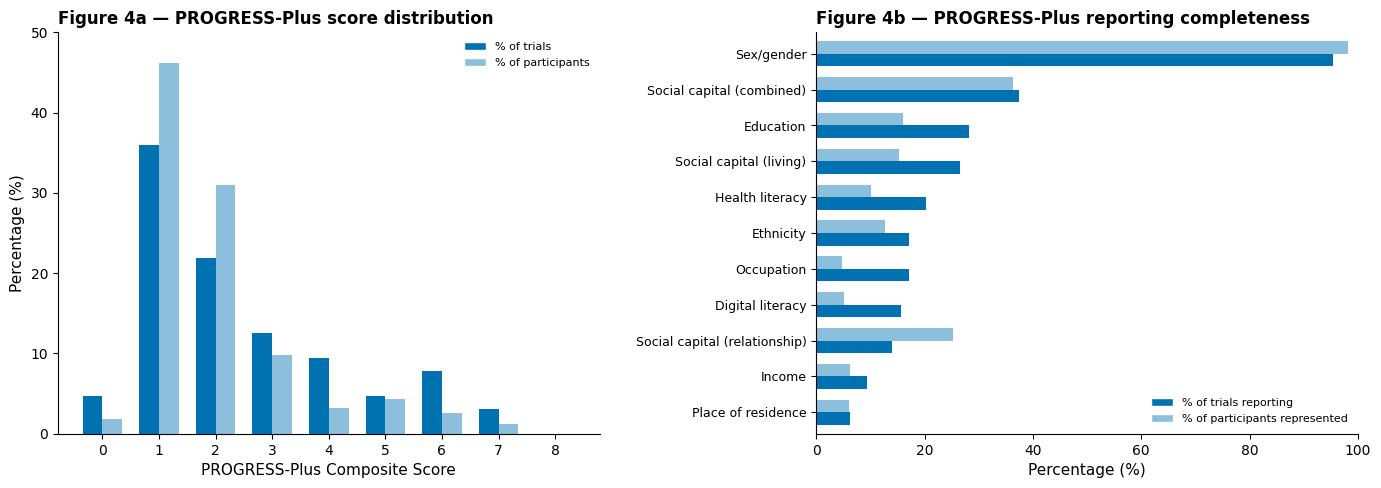

→ Thesis Figures 6 and 7


In [4]:
# Floor-shift: sex/gender is near-universal (61/64), creating a floor effect.
# Combined figure via build_fig4_combined().
has_sex = sum(1 for _, g in arms.groupby('cov_nr') if is_field_reported(g['gender_pct_female'], 'gender_pct_female').any())
has_hl = sum(1 for _, g in arms.groupby('cov_nr') if is_field_reported(g['health_literacy'], 'health_literacy').any())
has_dl = sum(1 for _, g in arms.groupby('cov_nr') if is_field_reported(g['digital_literacy'], 'digital_literacy').any())
print(f"\nFloor-shift analysis:")
print(f"  Sex/gender reported: {has_sex}/{len(papers)} (near-universal, but not automatic)")
print(f"  Health literacy (value=2): {has_hl}/{len(papers)}")
print(f"  Digital literacy (True): {has_dl}/{len(papers)}")
print(f"  True floor: 0 ({sum(1 for _, g in arms.groupby('cov_nr') if papers.set_index('cov_nr')['equity_score'].get(_) == 0)} papers score 0)")
print(f"  Theoretical range: 0-9; observed: 0-7 (max observed = 7)")

# Combined figure (trial count + participant count, normalised)
# Generate combined equity score + PROGRESS-Plus figure
from scripts.build_fig4_combined import build_fig4_combined
fig = build_fig4_combined(papers, arms)
save_figure(fig, "fig4_combined")
print("→ Thesis Figures 6 and 7")


## Section 3: Compute digital inclusiveness score

**Digital inclusiveness score (range 0–5)**

| excludes | equipment | training | support | usable_path | Score | Interpretation |
|---|---|---|---|---|---|---|
| 1 | 0 | 0 | 0 | 0 | **0** | Fully excluded, no mitigation |
| 1 | 0 | 1 | 0 | 0 | **0** | Training unusable |
| 1 | 0 | 0 | 1 | 0 | **0** | Support unusable |
| 1 | 0 | 1 | 1 | 0 | **0** | Both unusable |
| 1 | 1 | 0 | 0 | 1 | **1** | Excluded, equipment only |
| 1 | 1 | 1 | 0 | 1 | **2** | Excluded, equipment + training |
| 1 | 1 | 0 | 1 | 1 | **2** | Excluded, equipment + support |
| 1 | 1 | 1 | 1 | 1 | **3** | Excluded, full stack |
| 0 | 0 | 0 | 0 | 1 | **2** | Baseline inclusion |
| 0 | 0 | 1 | 0 | 1 | **3** | Baseline + training |
| 0 | 0 | 0 | 1 | 1 | **3** | Baseline + support |
| 0 | 0 | 1 | 1 | 1 | **4** | Baseline + both supports |
| 0 | 1 | 0 | 0 | 1 | **3** | Baseline + redundant equipment |
| 0 | 1 | 1 | 0 | 1 | **4** | Baseline + equipment + training |
| 0 | 1 | 0 | 1 | 1 | **4** | Baseline + equipment + support |
| 0 | 1 | 1 | 1 | 1 | **5** | Maximum inclusion |

Formula: `usable_path = (1 - excludes) OR equipment`, then `score = 2*(1-excludes) + equipment + (training & usable_path) + (support & usable_path)`.

N papers with digital score: 64/64
Digital inclusiveness score distribution:
count    64.000000
mean      2.062500
std       1.753681
min       0.000000
25%       0.000000
50%       2.000000
75%       3.000000
max       5.000000
Name: digital_inclusiveness_score, dtype: float64
digital_inclusiveness_score
0    21
1     3
2    13
3    12
4     8
5     7


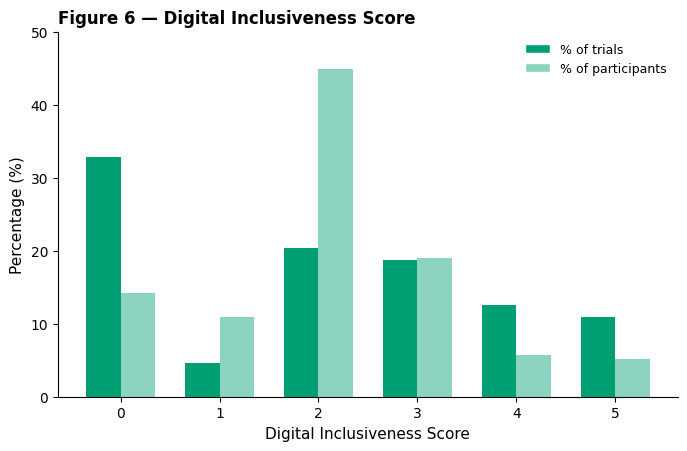

→ Thesis Figure 8


In [5]:
# Compute digital inclusiveness score (0–5) from 4 binary strategy flags.
# Conditional formula prevents training/support points when no usable path
# exists. Combined figure via build_fig6_combined().
ds_fields = [
    'digital_strategy_excludes', 'digital_strategy_provides_equipment',
    'digital_strategy_provides_training', 'digital_strategy_provides_ongoing_support',
]
ds_paper_vals = {}
for field in ds_fields:
    ds_paper_vals[field] = aggregate_boolean_at_paper(int_arms, field, method="any_true")

# Build digital inclusiveness DF and merge
dis_df = pd.DataFrame({
    'ds_excludes': ds_paper_vals['digital_strategy_excludes'],
    'ds_equipment': ds_paper_vals['digital_strategy_provides_equipment'],
    'ds_training': ds_paper_vals['digital_strategy_provides_training'],
    'ds_support': ds_paper_vals['digital_strategy_provides_ongoing_support'],
})
usable_path = (~dis_df['ds_excludes'].astype(bool) | dis_df['ds_equipment'].astype(bool))
dis_df['digital_inclusiveness_score'] = (
    2 * (~dis_df['ds_excludes'].astype(bool)).astype(int)
    + dis_df['ds_equipment'].astype(int)
    + (dis_df['ds_training'].astype(bool) & usable_path).astype(int)
    + (dis_df['ds_support'].astype(bool) & usable_path).astype(int)
)
papers = papers.merge(dis_df[['digital_inclusiveness_score']], left_on='cov_nr', right_index=True, how='left')
print(f"N papers with digital score: {papers['digital_inclusiveness_score'].notna().sum()}/{len(papers)}")

print("Digital inclusiveness score distribution:")
print(papers['digital_inclusiveness_score'].describe())
print(papers['digital_inclusiveness_score'].value_counts().sort_index().to_string())

# Combined figure (trial count + participant count, normalised)
# Generate digital inclusiveness score distribution figure
from scripts.build_fig6_combined import build_fig6_combined
fig = build_fig6_combined(papers)
save_figure(fig, "fig6_digital_inclusiveness_combined")
print("→ Thesis Figure 8")



## Section 4: Hypothesis 1 — Equity reporting over time

**Ordinary Least Squares (OLS)** is the method by which linear regression fits
a line through data. The “best” line minimises the sum of squared vertical
distances between each observed point and the line.

> **Why squared?** Squaring penalises large deviations disproportionately
> (a residual of 4 → 16; two residuals of 2 → 8 total). This makes OLS
> responsive to outliers — for better or worse. It also makes the math
> tractable (closed-form solution).

The output: an **intercept** (where the line crosses x=0) and a **slope** (β —
how much Y changes per unit increase in X), each with standard errors, CIs, and
p-values via the t-distribution.

**Key assumption:** the relationship between X and Y is linear. OLS will fit
a straight line to anything, even a curve. The diagnostic plots below tell you
whether linearity holds.

**LOWESS (Locally Weighted Scatterplot Smoothing)** is a non-parametric curve
fitted without assuming a specific functional form. It divides the X range into
small windows, fits a local regression in each, and connects them into a smooth
curve.

**Its purpose here:** a *reality check* on the OLS line. If the LOWESS curve
tracks the straight line closely, linearity is defensible. If it curves away,
the linear model is missing structure and the results should be interpreted
cautiously.

### Regression diagnostics

Three diagnostic panels accompany each regression:

**Residuals vs Fitted** — X-axis: predicted values. Y-axis: difference between
observed and predicted. What you want: random scatter around y=0 with no pattern.
A U-shape → non-linear relationship. A fan shape → non-constant variance
(heteroscedasticity), which can bias standard errors.

**QQ plot (Quantile-Quantile)** — X-axis: theoretical normal quantiles. Y-axis:
observed residual quantiles. Points on the 45° line = normal residuals, which
OLS assumes for exact p-values and CIs. Mild deviations are fine (central limit
theorem helps at n~60). Strong deviations — S-shape, heavy tails — mean p-values
may be miscalibrated.

**Cook's Distance** — how much each observation influences the regression fit.
Computed by refitting without observation i and measuring how much the predicted
values change. A common flag: Cook's distance > 4/n (≈ 0.06 at n=65). High
values are worth examining — they may be data errors, legitimate edge cases, or
observations that drive the result. The H1 sensitivity analysis below flags six
such observations and refits without them.


Papers for H1: 64


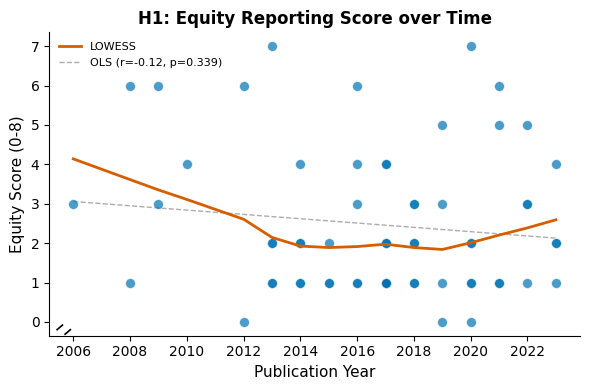

                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept          112.8819    114.667      0.984      0.329    -116.334     342.098
publication_year    -0.0547      0.057     -0.963      0.339      -0.168       0.059

H1: equity_score ~ publication_year
  beta = -0.055 [-0.168, 0.059], p = 0.3393, n = 64


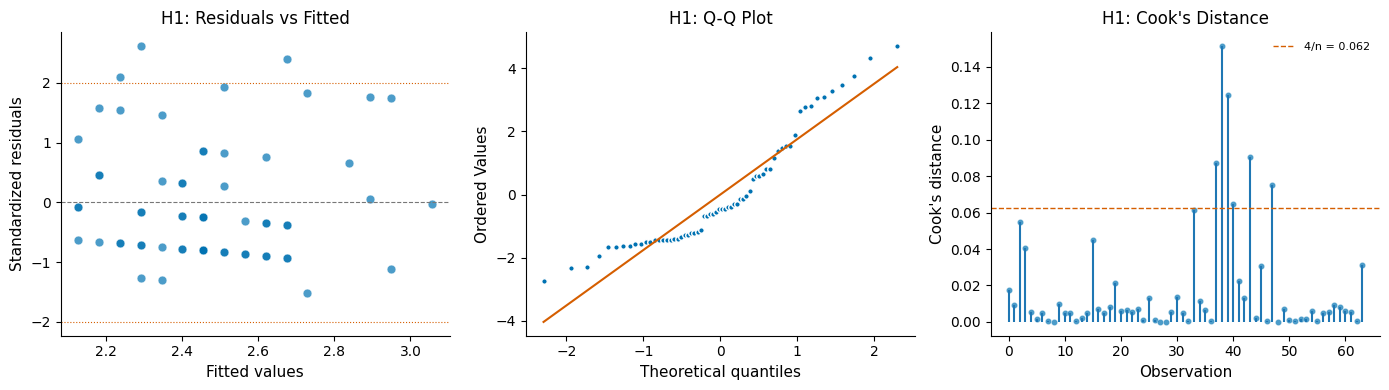

In [6]:
# H1: Has equity reporting improved over 2006–2023?
# OLS: equity_score ~ publication_year. LOWESS as linearity check.
# Three diagnostic panels: residuals, Q-Q, Cook's distance.
valid_h1 = papers[['equity_score', 'publication_year']].dropna()
n_h1 = len(valid_h1)
print(f"Papers for H1: {n_h1}")

fig = scatter_with_regression(
    valid_h1['publication_year'].values, valid_h1['equity_score'].values,
    xlabel='Publication Year', ylabel='Equity Score (0-8)',
    title='H1: Equity Reporting Score over Time', color=BLUE, integer_x=True,
)
save_figure(fig, "fig7a_h1_equity_over_time")

# Linear regression
model_h1 = smf.ols('equity_score ~ publication_year', data=valid_h1).fit()
print(model_h1.summary().tables[1])

beta = model_h1.params['publication_year']
ci = model_h1.conf_int().loc['publication_year']
p_val = model_h1.pvalues['publication_year']
print(f"\nH1: equity_score ~ publication_year")
print(f"  beta = {beta:.3f} [{ci[0]:.3f}, {ci[1]:.3f}], p = {p_val:.4f}, n = {n_h1}")

fig_diag = regression_diagnostics_plot(model_h1, title_prefix="H1: ")
save_figure(fig_diag, "fig7b_h1_diagnostics")


## Section 5: Hypothesis 2 — Representativeness over time

**Arm-level sensitivity with cluster-robust SEs**

The primary H2 runs at paper-level (one mean per trial). The arm-level sensitivity
uses each arm as an observation.

**Why this matters:** multi-arm trials contribute 2+ mean ages. The arm-level
analysis increases observations and captures within-trial variation (e.g.,
treatment arm younger than control). However, arms within a trial share inclusion
criteria and protocol, so their ages are correlated — violating the OLS
assumption of independent observations.

**Cluster-robust standard errors** (sandwich estimator) adjust for this
non-independence by allowing errors to be correlated within `cov_nr` clusters.
- If arms within a trial are near-identical → cluster SE ≈ paper-level SE
- If arms differ (different populations per arm) → arm-level estimates diverge

The trade-off: the cluster estimator is asymptotically justified (needs *many*
clusters). With 59 clusters, we are at the borderline where cluster SEs can be
unreliable (Cameron & Miller 2015). The paper-level result is primary; the
arm-level result is a sensitivity check, reported cautiously.


H2a: Mean age vs year
  beta = -0.125 [-0.326, 0.076], p = 0.2168, n = 59
H2b: FEV1% predicted vs year
  beta = 0.172 [-0.444, 0.788], p = 0.5762, n = 49


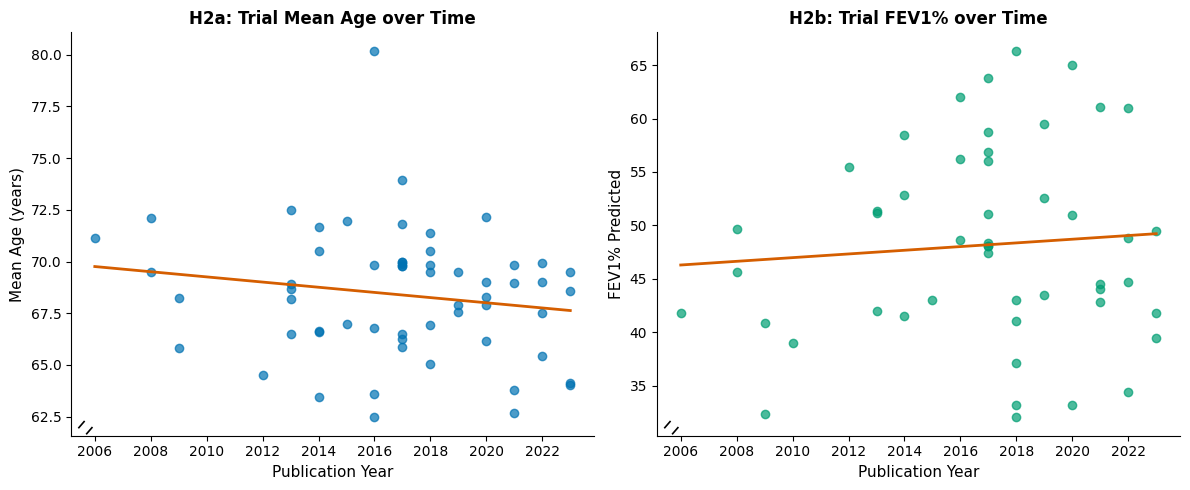

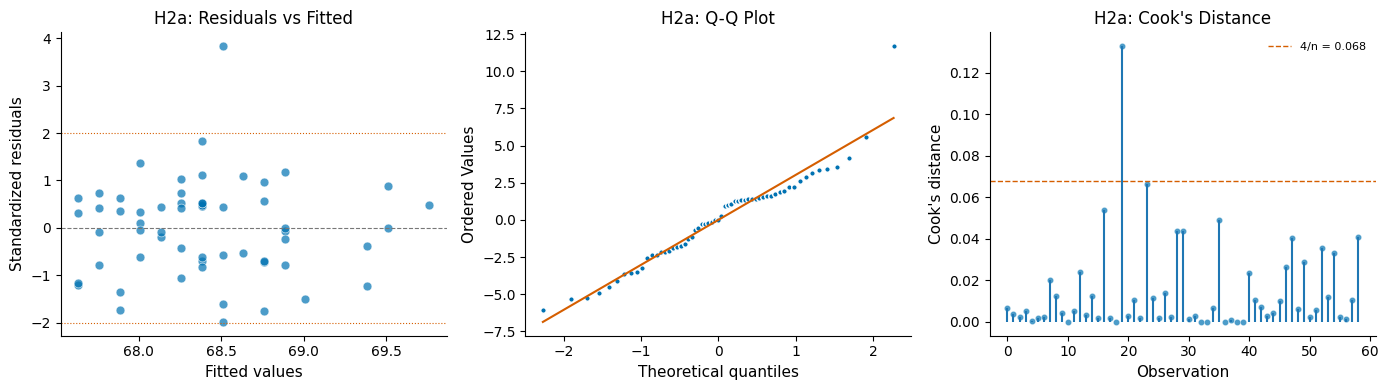

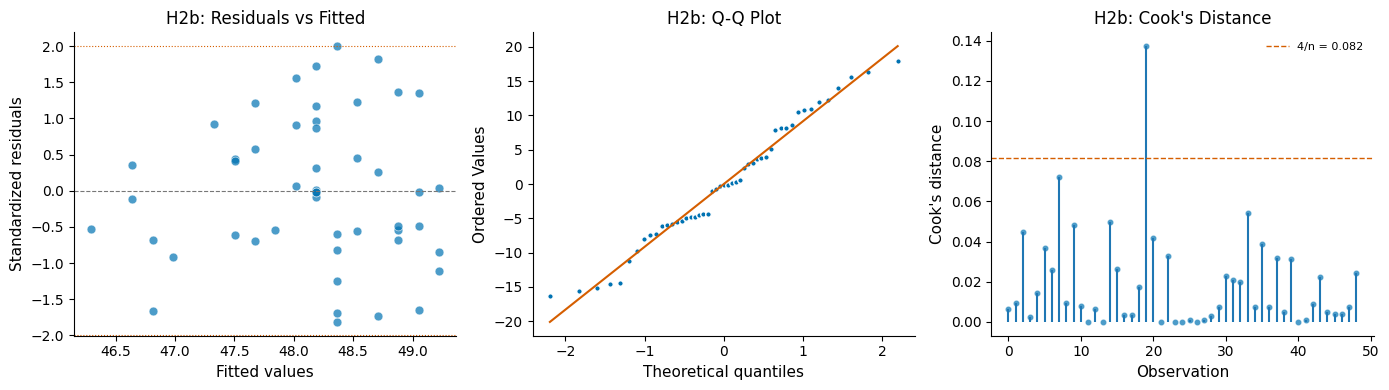


H2a arm-level (cluster-robust SE):
  beta = -0.166 [-0.331, -0.000], p = 0.0494, n_obs = 100

H2b arm-level (cluster-robust SE):
  beta = 0.075 [-0.452, 0.603], p = 0.7798, n_obs = 100


In [7]:
# H2: Have enrolled populations changed over time?
# H2a: age_mean ~ year. H2b: fev1_pct_mean ~ year.
# Arm-level sensitivity uses cluster-robust SEs (arms within trial
# not independent). n_clusters=59, borderline reliable.
# H2a: age over time
valid_age = papers[['age_mean', 'publication_year']].dropna()
model_h2_age = smf.ols('age_mean ~ publication_year', data=valid_age).fit()
beta_age = model_h2_age.params['publication_year']
ci_age = model_h2_age.conf_int().loc['publication_year']
p_age = model_h2_age.pvalues['publication_year']
print(f"H2a: Mean age vs year")
print(f"  beta = {beta_age:.3f} [{ci_age[0]:.3f}, {ci_age[1]:.3f}], p = {p_age:.4f}, n = {len(valid_age)}")

# H2b: FEV1% over time
valid_fev1 = papers[['fev1_pct_mean', 'publication_year']].dropna()
model_h2_fev1 = smf.ols('fev1_pct_mean ~ publication_year', data=valid_fev1).fit()
beta_fev1 = model_h2_fev1.params['publication_year']
ci_fev1 = model_h2_fev1.conf_int().loc['publication_year']
p_fev1 = model_h2_fev1.pvalues['publication_year']
print(f"H2b: FEV1% predicted vs year")
print(f"  beta = {beta_fev1:.3f} [{ci_fev1[0]:.3f}, {ci_fev1[1]:.3f}], p = {p_fev1:.4f}, n = {len(valid_fev1)}")

# Scatter plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.scatter(valid_age['publication_year'], valid_age['age_mean'], color=BLUE, alpha=0.7)
add_axis_break(ax1)
xr = np.linspace(valid_age['publication_year'].min(), valid_age['publication_year'].max(), 50)
ax1.plot(xr, model_h2_age.params['Intercept'] + model_h2_age.params['publication_year'] * xr, color=RED, linewidth=2)
ax1.set_xlabel('Publication Year'); ax1.set_ylabel('Mean Age (years)')
ax1.set_title('H2a: Trial Mean Age over Time', fontweight='bold')
ax1.xaxis.set_major_locator(MaxNLocator(integer=True))

ax2.scatter(valid_fev1['publication_year'], valid_fev1['fev1_pct_mean'], color=GREEN, alpha=0.7)
add_axis_break(ax2)
xr2 = np.linspace(valid_fev1['publication_year'].min(), valid_fev1['publication_year'].max(), 50)
ax2.plot(xr2, model_h2_fev1.params['Intercept'] + model_h2_fev1.params['publication_year'] * xr2, color=RED, linewidth=2)
ax2.set_xlabel('Publication Year'); ax2.set_ylabel('FEV1% Predicted')
ax2.set_title('H2b: Trial FEV1% over Time', fontweight='bold')
ax2.xaxis.set_major_locator(MaxNLocator(integer=True))
fig.tight_layout()
save_figure(fig, "fig8a_h2_age_and_fev1_over_time")

# Diagnostics
fig_d2 = regression_diagnostics_plot(model_h2_age, title_prefix="H2a: ")
save_figure(fig_d2, "fig8b_h2_age_diagnostics")
fig_d2b = regression_diagnostics_plot(model_h2_fev1, title_prefix="H2b: ")
save_figure(fig_d2b, "fig8c_h2_fev1_diagnostics")

# Arm-level sensitivity with cluster-robust SEs
arm_data = arms[['cov_nr', 'age_mean', 'fev1_pct_mean']].dropna(subset=['age_mean'])
arm_data = arm_data.merge(papers[['cov_nr', 'publication_year']], on='cov_nr', how='inner')
arm_data = arm_data.dropna()

model_h2_age_arm = smf.ols('age_mean ~ publication_year', data=arm_data).fit(
    cov_type='cluster', cov_kwds={'groups': arm_data['cov_nr']}
)
beta_age_arm = model_h2_age_arm.params['publication_year']
ci_age_arm = model_h2_age_arm.conf_int().loc['publication_year']
p_age_arm = model_h2_age_arm.pvalues['publication_year']
print(f"\nH2a arm-level (cluster-robust SE):")
print(f"  beta = {beta_age_arm:.3f} [{ci_age_arm[0]:.3f}, {ci_age_arm[1]:.3f}], p = {p_age_arm:.4f}, n_obs = {len(arm_data)}")

arm_data_fev1 = arms[['cov_nr', 'age_mean', 'fev1_pct_mean']].dropna(subset=['fev1_pct_mean'])
arm_data_fev1 = arm_data_fev1.merge(papers[['cov_nr', 'publication_year']], on='cov_nr', how='inner')
arm_data_fev1 = arm_data_fev1.dropna()

model_h2_fev1_arm = smf.ols('fev1_pct_mean ~ publication_year', data=arm_data_fev1).fit(
    cov_type='cluster', cov_kwds={'groups': arm_data_fev1['cov_nr']}
)
beta_fev1_arm = model_h2_fev1_arm.params['publication_year']
ci_fev1_arm = model_h2_fev1_arm.conf_int().loc['publication_year']
p_fev1_arm = model_h2_fev1_arm.pvalues['publication_year']
print(f"\nH2b arm-level (cluster-robust SE):")
print(f"  beta = {beta_fev1_arm:.3f} [{ci_fev1_arm[0]:.3f}, {ci_fev1_arm[1]:.3f}], p = {p_fev1_arm:.4f}, n_obs = {len(arm_data_fev1)}")


## Section 6: Hypothesis 3 — Equity vs digital inclusiveness

**Collinearity check & Pearson r**

Before running the regression, we check whether the equity score (0–7) and
digital inclusiveness score (0–3) are collinear. These scores capture different
constructs (demographic reporting vs. digital strategy design), but trials with
equity-awareness may also be more digitally inclusive — so a check is warranted.

**Collinearity** occurs when two predictors are highly correlated. When they
are, the regression cannot separate their individual effects: standard errors
inflate, coefficients become unstable, and conclusions about which predictor
is driving the outcome are unreliable.

**Variance Inflation Factor (VIF)** quantifies how much each predictor's
variance is inflated due to correlation with other predictors. VIF = 1 means no
inflation (orthogonal predictors). Thresholds: VIF > 5 or > 10 are commonly
flagged as problematic.

The diagnostic flow:
1. **Pearson r** between equity score and publication year (bivariate check)
2. **VIF** from a model containing both predictors
3. If |r| ≥ 0.7 or VIF > 5, the model is refit with a single predictor

> H2 has only one predictor (publication_year). Collinearity requires ≥ 2
> variables, so H2 does not need this check. H3 has two predictors — hence the
> diagnostics here.

> **Diagnostic note (residuals vs fitted):** The residuals-vs-fitted plot for H3
> shows a mild pattern deviating from random scatter around zero, suggesting some
> heteroscedasticity. OLS p-values may be slightly anti-conservative as a result;
> coefficients should be interpreted with caution. This is noted in the
> limitations section of the thesis.


Pearson r(equity_score, year) = -0.121 (p=0.339)
VIF:
equity_score        2.856091
publication_year    2.856091

H3 primary model:
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept          -24.7423    112.588     -0.220      0.827    -249.876     200.391
equity_score         0.0470      0.124      0.380      0.705      -0.200       0.294
publication_year     0.0132      0.056      0.237      0.813      -0.098       0.125

H3: digital_inclusiveness ~ equity_score + year
  beta_equity = 0.047 [-0.200, 0.294], p = 0.7052, n = 64


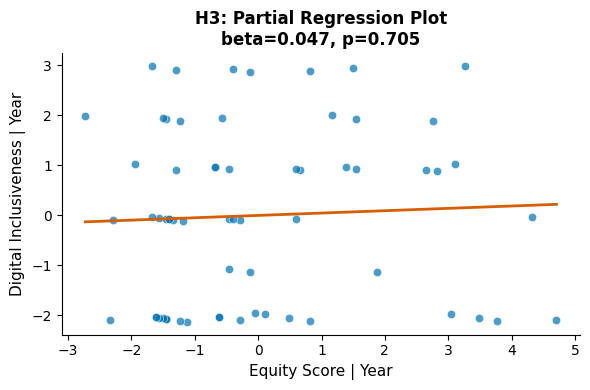

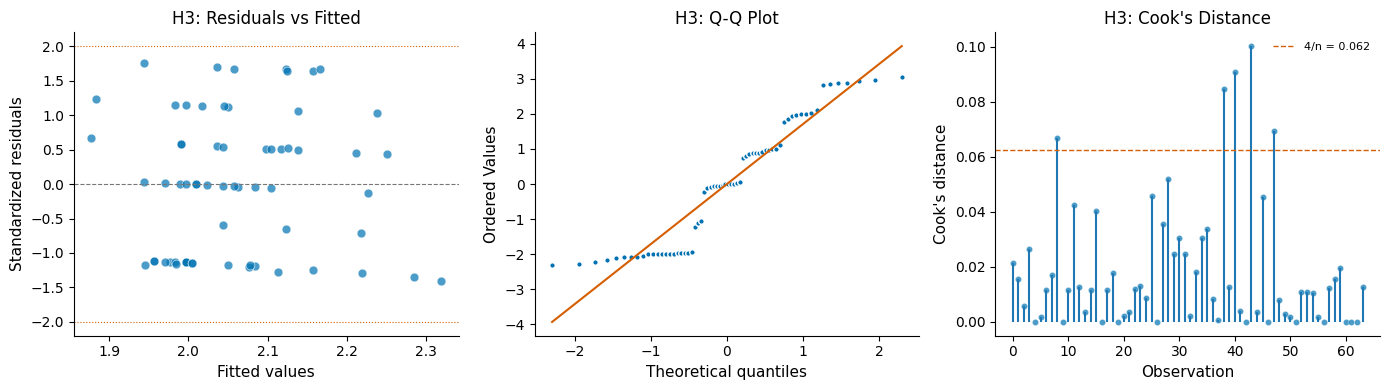

In [8]:
# H3: Are equity-conscious trials more digitally inclusive?
# Collinearity check first (VIF > 5 = problematic, |r| > 0.7).
# OLS: digital_inclusiveness ~ equity_score + year.
valid_h3 = papers[['equity_score', 'digital_inclusiveness_score', 'publication_year']].dropna()
n_h3 = len(valid_h3)

# Collinearity check
r, r_p = pearson_correlation(valid_h3['equity_score'].tolist(), valid_h3['publication_year'].tolist())
print(f"Pearson r(equity_score, year) = {r:.3f} (p={r_p:.3f})")

vif = vif_from_model(valid_h3[['equity_score', 'publication_year']])
print("VIF:")
print(vif.to_string())

if abs(r) >= 0.7:
    print("⚠️ Collinearity |r| >= 0.7: will also fit unadjusted model")

# Primary model
model_h3 = smf.ols('digital_inclusiveness_score ~ equity_score + publication_year', data=valid_h3).fit()
print("\nH3 primary model:")
print(model_h3.summary().tables[1])

beta_h3 = model_h3.params['equity_score']
ci_h3 = model_h3.conf_int().loc['equity_score']
p_h3 = model_h3.pvalues['equity_score']
print(f"\nH3: digital_inclusiveness ~ equity_score + year")
print(f"  beta_equity = {beta_h3:.3f} [{ci_h3[0]:.3f}, {ci_h3[1]:.3f}], p = {p_h3:.4f}, n = {n_h3}")

# Unadjusted if collinear
if abs(r) >= 0.7:
    model_h3_unadj = smf.ols('digital_inclusiveness_score ~ equity_score', data=valid_h3).fit()
    print("\nH3 unadjusted:")
    print(model_h3_unadj.summary().tables[1])

# Partial regression plot
resid_y = smf.ols('digital_inclusiveness_score ~ publication_year', data=valid_h3).fit().resid
resid_x = smf.ols('equity_score ~ publication_year', data=valid_h3).fit().resid

fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(resid_x, resid_y, color=BLUE, alpha=0.7, edgecolors='white', linewidth=0.5)
add_axis_break(ax)
beta_partial = np.polyfit(resid_x, resid_y, 1)[0]
xr = np.linspace(resid_x.min(), resid_x.max(), 50)
ax.plot(xr, beta_partial * xr, color=RED, linewidth=2)
ax.set_xlabel('Equity Score | Year')
ax.set_ylabel('Digital Inclusiveness | Year')
ax.set_title(f'H3: Partial Regression Plot\nbeta={beta_partial:.3f}, p={p_h3:.3f}', fontweight='bold')
fig.tight_layout()
save_figure(fig, "fig9a_h3_equity_vs_digital")

# Diagnostics
fig_d3 = regression_diagnostics_plot(model_h3, title_prefix="H3: ")
save_figure(fig_d3, "fig9b_h3_diagnostics")


## Section 7: Compile results table

In [9]:
results_rows = [
    {
        'hypothesis': 'H1', 'predictor': 'publication_year',
        'outcome': 'equity_score',
        'beta': model_h1.params['publication_year'],
        'ci_lower': model_h1.conf_int().loc['publication_year', 0],
        'ci_upper': model_h1.conf_int().loc['publication_year', 1],
        'raw_p': model_h1.pvalues['publication_year'], 'n': n_h1,
    },
    {
        'hypothesis': 'H2a_age', 'predictor': 'publication_year',
        'outcome': 'age_mean',
        'beta': beta_age, 'ci_lower': ci_age[0], 'ci_upper': ci_age[1],
        'raw_p': p_age, 'n': len(valid_age),
    },
    {
        'hypothesis': 'H2b_fev1', 'predictor': 'publication_year',
        'outcome': 'fev1_pct_mean',
        'beta': beta_fev1, 'ci_lower': ci_fev1[0], 'ci_upper': ci_fev1[1],
        'raw_p': p_fev1, 'n': len(valid_fev1),
    },
    {
        'hypothesis': 'H3', 'predictor': 'equity_score (adj. year)',
        'outcome': 'digital_inclusiveness_score',
        'beta': beta_h3, 'ci_lower': ci_h3[0], 'ci_upper': ci_h3[1],
        'raw_p': p_h3, 'n': n_h3,
    },
]

results_df = pd.DataFrame(results_rows)
results_df.to_csv(OUTPUT_TABLES / 'table6a_inferential_results.csv', index=False)
print("Saved: table6_inferential_results.csv")
print(results_df.to_string())

# Summary
summary = {f'{r["hypothesis"]}_{k}': v for r in results_rows
           for k, v in r.items() if k != 'hypothesis'}
pd.DataFrame([summary]).to_csv(OUTPUT_TABLES / 'table6b_inferential_summary.csv', index=False)
print("\nSaved: inferential_summary.csv")


Saved: table6_inferential_results.csv
  hypothesis                 predictor                      outcome      beta  ci_lower  ci_upper     raw_p   n
0         H1          publication_year                 equity_score -0.054748 -0.168404  0.058908  0.339337  64
1    H2a_age          publication_year                     age_mean -0.125172 -0.325867  0.075523  0.216799  59
2   H2b_fev1          publication_year                fev1_pct_mean  0.172326 -0.443540  0.788191  0.576174  49
3         H3  equity_score (adj. year)  digital_inclusiveness_score  0.047027 -0.200395  0.294448  0.705218  64

Saved: inferential_summary.csv


In [10]:
# ── RESULTS-READY SENTENCES ────────────────────────────────────────────
# Copy-pasteable English sentences matching thesis style.
# Uses N04's own model variables (model_h1, model_h2_age, model_h2_fev1).

h1_beta = model_h1.params["publication_year"]
h1_ci = model_h1.conf_int().loc["publication_year"]
h1_p = model_h1.pvalues["publication_year"]
print(f"H1: Each additional year was associated with a {h1_beta:.3f} change in equity score "
      f"(95% CI [{h1_ci[0]:.3f}, {h1_ci[1]:.3f}], p = {h1_p:.4f}, n = {len(valid_h1)}).")

h2a_beta = model_h2_age.params["publication_year"]
h2a_ci = model_h2_age.conf_int().loc["publication_year"]
h2a_p = model_h2_age.pvalues["publication_year"]
print(f"\nH2a: Each additional year was associated with a {h2a_beta:.3f}-year change in mean age "
      f"(95% CI [{h2a_ci[0]:.3f}, {h2a_ci[1]:.3f}], p = {h2a_p:.4f}, n = {len(valid_age)}).")

h2b_beta = model_h2_fev1.params["publication_year"]
h2b_ci = model_h2_fev1.conf_int().loc["publication_year"]
h2b_p = model_h2_fev1.pvalues["publication_year"]
print(f"\nH2b: Each additional year was associated with a {h2b_beta:.3f} percentage-point change "
      f"in FEV1% predicted "
      f"(95% CI [{h2b_ci[0]:.3f}, {h2b_ci[1]:.3f}], p = {h2b_p:.4f}, n = {len(valid_fev1)}).")

# H3 model refit (data built from papers to avoid cross-cell dependencies)
h3_data = papers[["digital_inclusiveness_score", "equity_score", "publication_year"]].dropna()
h3_model = smf.ols("digital_inclusiveness_score ~ equity_score + publication_year", data=h3_data).fit()
h3_beta = h3_model.params["equity_score"]
h3_ci = h3_model.conf_int().loc["equity_score"]
h3_p = h3_model.pvalues["equity_score"]
print(f"\nH3: Each additional equity domain reported was associated with a {h3_beta:.3f} "
      f"change in digital inclusiveness score "
      f"(95% CI [{h3_ci[0]:.3f}, {h3_ci[1]:.3f}], p = {h3_p:.4f}, n = {len(h3_data)}), "
      f"adjusted for publication year.")


H1: Each additional year was associated with a -0.055 change in equity score (95% CI [-0.168, 0.059], p = 0.3393, n = 64).

H2a: Each additional year was associated with a -0.125-year change in mean age (95% CI [-0.326, 0.076], p = 0.2168, n = 59).

H2b: Each additional year was associated with a 0.172 percentage-point change in FEV1% predicted (95% CI [-0.444, 0.788], p = 0.5762, n = 49).

H3: Each additional equity domain reported was associated with a 0.047 change in digital inclusiveness score (95% CI [-0.200, 0.294], p = 0.7052, n = 64), adjusted for publication year.


## Section 8: Thesis-ready result statements

In [11]:
print("=== Notebook 04 complete ===")
print(f"Completed at: {pd.Timestamp.now().isoformat()}")

=== Notebook 04 complete ===
Completed at: 2026-06-08T18:47:52.461571


In [12]:
print(f"=== Notebook 04 completed at: {pd.Timestamp.now().isoformat()}")

=== Notebook 04 completed at: 2026-06-08T18:47:52.500661
